In [19]:
!pip install scikit-image watermark -q

# Install OpenCV package first
!pip install opencv-python -q

# First install the required system library
!apt-get update && apt-get install -y libgl1-mesa-glx

!pip install opencv-python

!pip install pillow


[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Get:1 http://deb.debian.org/debian bullseye InRelease [116 kB]
Get:2 http://deb.debian.org/debian-security bullseye-security InRelease [27.1 kB]
Get:3 http://deb.debian.org/debian bullseye-updates InRelease [44.1 kB]
Get:4 http://deb.debian.org/debian bullseye/main amd64 Packages [8,066 kB]
Get:5 http://deb.debian.org/debian-security bullseye-security/main amd64 Packages [362 kB]
Get:6 http://deb.debian.org/debian bullseye-updates/main amd64 Packages [18.8 kB]
Fetched 8,634 kB in 5s (1,850 kB/s)




The following additional packages will be installed:
  libdrm-amdgpu1 libdrm-common libdrm-intel1 libdrm-nouveau2 libdrm-radeon1
  libdrm2 libgl1 libgl1-mesa-dri libglapi-mesa libglvnd0 libglx-mesa0 libglx0
  libllvm11 libpciaccess0 libsensors-config libsensors5 libvul

In [20]:
import numpy as np
import cv2
from cv2 import imread
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import os

# Catálogo de Imágenes procesadas

Este catálogo presenta una selección de imágenes utilizadas en distintos proyectos de procesamiento digital. 

Imágenes obtenidas de Pinterest https://in.pinterest.com/today/

Cada entrada incluye:
* El título que identifica el proyecto o la técnica aplicada.
* La imagen representativa del trabajo realizado.
* Una barra de color que resume los tonos predominantes de la imagen.
* El modo de visualización del color (en este caso, RGB).
* El formato del archivo (por ejemplo, JPEG).
* El tamaño expresado en ancho y alto de píxeles.
* La memoria ocupada, indicando el espacio que requiere el archivo.
* El tipo de dato que describe cómo están codificados los valores de color en la imagen (uint8), un formato estándar que representa intensidades de color de 0 a 255.

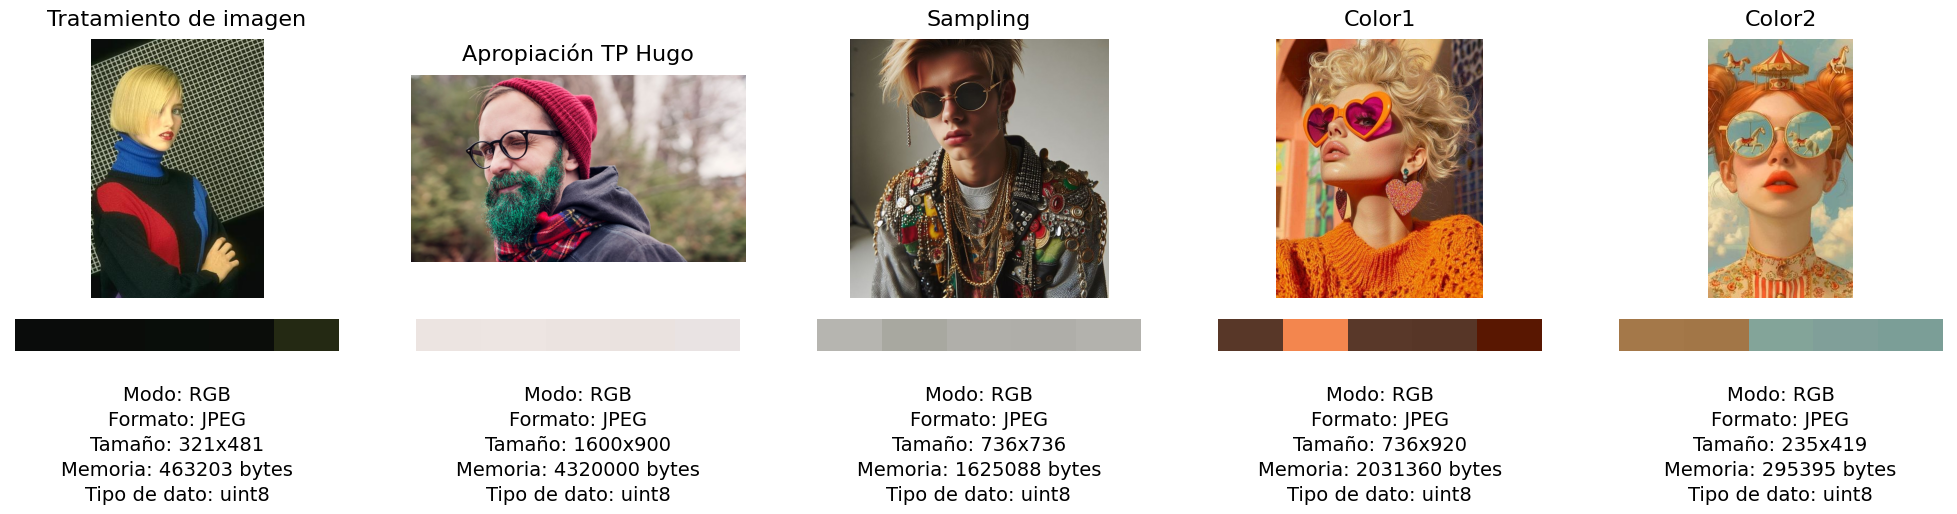

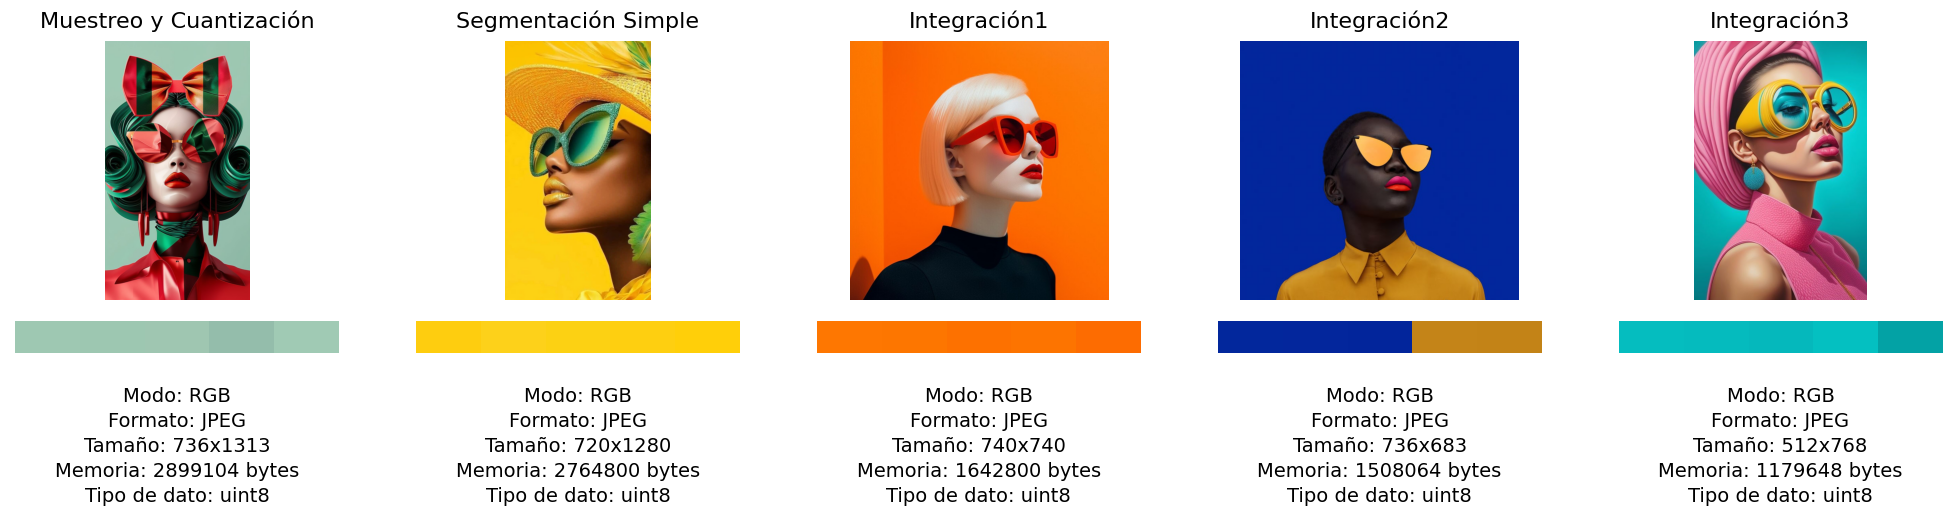

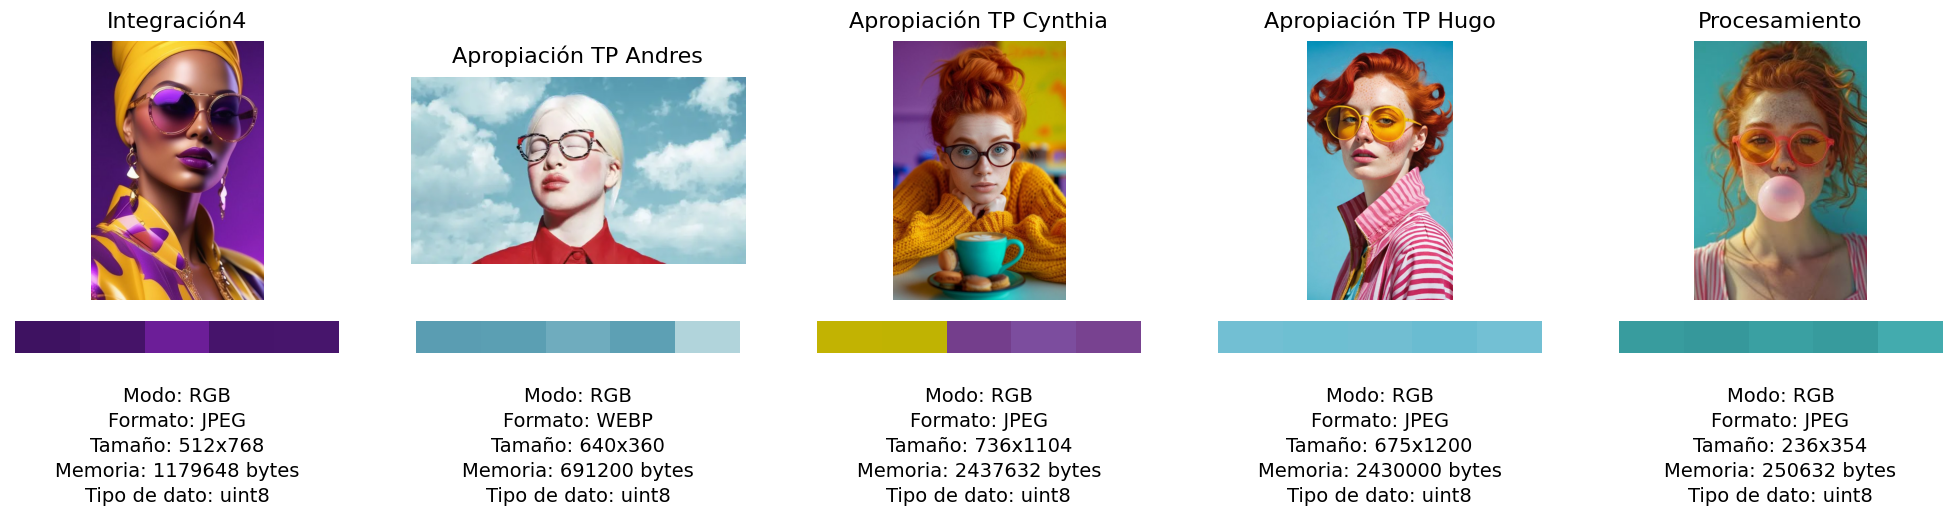

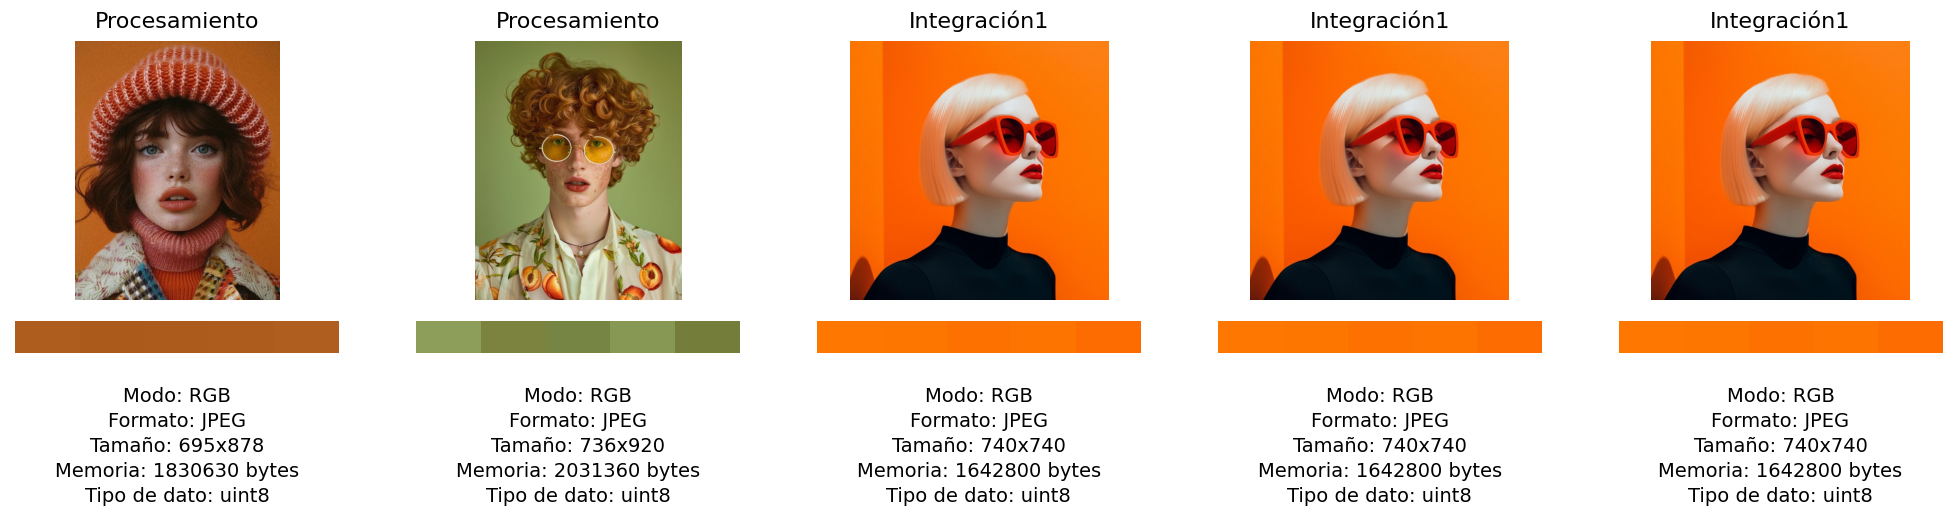

In [23]:
#1ra línea de imagenes

def get_image_info(img_path):
    img = Image.open(img_path).convert('RGB')
    arr = np.array(img)
    formato = Image.open(img_path).format
    modo = img.mode
    dtype = arr.dtype
    size_bytes = arr.nbytes
    shape = arr.shape
    return arr, f"Modo: {modo}\nFormato: {formato}\nTamaño: {shape[1]}x{shape[0]}\nMemoria: {size_bytes} bytes\nTipo de dato: {dtype}"

def get_palette(arr, num_colors=5):
    arr_reshaped = arr.reshape(-1, 3)
    unique_colors, counts = np.unique(arr_reshaped, axis=0, return_counts=True)
    top_colors = unique_colors[np.argsort(-counts)[:num_colors]]
    return top_colors

# Imágenes y títulos
files = ['198023.jpg', 'beard.jpg', 'Textura1.jpg', 'gafas3.jpg', 'gafas2.jpg']
titles = ['Tratamiento de imagen', 'Apropiación TP Hugo', 'Sampling', 'Color1', 'Color2']

# Figura con filas ajustadas: imagen, paleta finita, texto
fig, axs = plt.subplots(3, 5, figsize=(25, 6), gridspec_kw={'height_ratios': [4, 0.5, 2]})

for i, (file, title) in enumerate(zip(files, titles)):
    img, desc = get_image_info(file)
    colors = get_palette(img)

    # Imagen
    axs[0, i].imshow(img)
    axs[0, i].axis("off")
    axs[0, i].set_title(title, fontsize=16, pad=10)

    # Paleta más finita
    palette = np.ones((10, 100, 3), dtype=np.uint8) * 255  # ← altura = 10
    for j, color in enumerate(colors):
        start = j * (100 // len(colors))
        end = (j + 1) * (100 // len(colors))
        palette[:, start:end] = color
    axs[1, i].imshow(palette)
    axs[1, i].axis("off")

    # Descripción
    axs[2, i].axis("off")
    axs[2, i].text(0.5, 0.9, desc, ha='center', va='top', fontsize=14, wrap=True, linespacing=1.4)

# Menor espacio vertical
fig.subplots_adjust(hspace=0.15)

plt.show()


#-------------------------------------------------------------------------------------------------------
#2da línea de imagenes

def get_image_info(img_path):
    img = Image.open(img_path).convert('RGB')
    arr = np.array(img)
    formato = Image.open(img_path).format
    modo = img.mode
    dtype = arr.dtype
    size_bytes = arr.nbytes
    shape = arr.shape
    return arr, f"Modo: {modo}\nFormato: {formato}\nTamaño: {shape[1]}x{shape[0]}\nMemoria: {size_bytes} bytes\nTipo de dato: {dtype}"

def get_palette(arr, num_colors=5):
    arr_reshaped = arr.reshape(-1, 3)
    unique_colors, counts = np.unique(arr_reshaped, axis=0, return_counts=True)
    top_colors = unique_colors[np.argsort(-counts)[:num_colors]]
    return top_colors

# Imágenes y títulos
files = ['gafas10.jpg', 'gafas7.jpg', 'gafas.jpg', 'gafas1.jpg', 'gafas8.jpg']
titles = ['Muestreo y Cuantización', 'Segmentación Simple', 'Integración1', 'Integración2', 'Integración3']

# Figura con filas ajustadas: imagen, paleta finita, texto
fig, axs = plt.subplots(3, 5, figsize=(25, 6), gridspec_kw={'height_ratios': [4, 0.5, 2]})

for i, (file, title) in enumerate(zip(files, titles)):
    img, desc = get_image_info(file)
    colors = get_palette(img)

    # Imagen
    axs[0, i].imshow(img)
    axs[0, i].axis("off")
    axs[0, i].set_title(title, fontsize=16, pad=10)

    # Paleta más finita
    palette = np.ones((10, 100, 3), dtype=np.uint8) * 255  # ← altura = 10
    for j, color in enumerate(colors):
        start = j * (100 // len(colors))
        end = (j + 1) * (100 // len(colors))
        palette[:, start:end] = color
    axs[1, i].imshow(palette)
    axs[1, i].axis("off")

    # Descripción
    axs[2, i].axis("off")
    axs[2, i].text(0.5, 0.9, desc, ha='center', va='top', fontsize=14, wrap=True, linespacing=1.4)

# Menor espacio vertical
fig.subplots_adjust(hspace=0.15)

plt.show()


#-------------------------------------------------------------------------------------------------------
#3ra línea de imagenes

def get_image_info(img_path):
    img = Image.open(img_path).convert('RGB')
    arr = np.array(img)
    formato = Image.open(img_path).format
    modo = img.mode
    dtype = arr.dtype
    size_bytes = arr.nbytes
    shape = arr.shape
    return arr, f"Modo: {modo}\nFormato: {formato}\nTamaño: {shape[1]}x{shape[0]}\nMemoria: {size_bytes} bytes\nTipo de dato: {dtype}"

def get_palette(arr, num_colors=5):
    arr_reshaped = arr.reshape(-1, 3)
    unique_colors, counts = np.unique(arr_reshaped, axis=0, return_counts=True)
    top_colors = unique_colors[np.argsort(-counts)[:num_colors]]
    return top_colors

# Imágenes y títulos
files = ['gafas9.jpg', 'cielo.jpg', 'taza.jpg', 'gafas11.jpg', 'chicle.jpg']
titles = ['Integración4', 'Apropiación TP Andres', 'Apropiación TP Cynthia', 'Apropiación TP Hugo', 'Procesamiento']

# Figura con filas ajustadas: imagen, paleta finita, texto
fig, axs = plt.subplots(3, 5, figsize=(25, 6), gridspec_kw={'height_ratios': [4, 0.5, 2]})

for i, (file, title) in enumerate(zip(files, titles)):
    img, desc = get_image_info(file)
    colors = get_palette(img)

    # Imagen
    axs[0, i].imshow(img)
    axs[0, i].axis("off")
    axs[0, i].set_title(title, fontsize=16, pad=10)

    # Paleta más finita
    palette = np.ones((10, 100, 3), dtype=np.uint8) * 255  # ← altura = 10
    for j, color in enumerate(colors):
        start = j * (100 // len(colors))
        end = (j + 1) * (100 // len(colors))
        palette[:, start:end] = color
    axs[1, i].imshow(palette)
    axs[1, i].axis("off")

    # Descripción
    axs[2, i].axis("off")
    axs[2, i].text(0.5, 0.9, desc, ha='center', va='top', fontsize=14, wrap=True, linespacing=1.4)

# Menor espacio vertical
fig.subplots_adjust(hspace=0.15)

plt.show()


#-------------------------------------------------------------------------------------------------------
#4ta línea de imagenes

def get_image_info(img_path):
    img = Image.open(img_path).convert('RGB')
    arr = np.array(img)
    formato = Image.open(img_path).format
    modo = img.mode
    dtype = arr.dtype
    size_bytes = arr.nbytes
    shape = arr.shape
    return arr, f"Modo: {modo}\nFormato: {formato}\nTamaño: {shape[1]}x{shape[0]}\nMemoria: {size_bytes} bytes\nTipo de dato: {dtype}"

def get_palette(arr, num_colors=5):
    arr_reshaped = arr.reshape(-1, 3)
    unique_colors, counts = np.unique(arr_reshaped, axis=0, return_counts=True)
    top_colors = unique_colors[np.argsort(-counts)[:num_colors]]
    return top_colors

# Imágenes y títulos
files = ['gorro.jpg', 'frutal.jpg', 'gafas.jpg', 'gafas.jpg', 'gafas.jpg']
titles = ['Procesamiento', 'Procesamiento', 'Integración1', 'Integración1', 'Integración1']

# Figura con filas ajustadas: imagen, paleta finita, texto
fig, axs = plt.subplots(3, 5, figsize=(25, 6), gridspec_kw={'height_ratios': [4, 0.5, 2]})

for i, (file, title) in enumerate(zip(files, titles)):
    img, desc = get_image_info(file)
    colors = get_palette(img)

    # Imagen
    axs[0, i].imshow(img)
    axs[0, i].axis("off")
    axs[0, i].set_title(title, fontsize=16, pad=10)

    # Paleta más finita
    palette = np.ones((10, 100, 3), dtype=np.uint8) * 255  # ← altura = 10
    for j, color in enumerate(colors):
        start = j * (100 // len(colors))
        end = (j + 1) * (100 // len(colors))
        palette[:, start:end] = color
    axs[1, i].imshow(palette)
    axs[1, i].axis("off")

    # Descripción
    axs[2, i].axis("off")
    axs[2, i].text(0.5, 0.9, desc, ha='center', va='top', fontsize=14, wrap=True, linespacing=1.4)

# Menor espacio vertical
fig.subplots_adjust(hspace=0.15)

plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=9be9d3e5-4f25-48e6-912d-b59b8644d952' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>